In [1]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

In [ ]:
def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "Add_Util"])
    configs[f"{name_prefix}add"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}bal"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}fair"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}fair_bal"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{len(teams_)}_fair_bal"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}rawl"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}rawl_bal"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Separate Theories": "blue",
    "Act-Utilitarianism": "black",
    "Fairness": "green",
    "Rawls": "red",
    "Fair + balance": "cyan",
    "Rawls + balance": "magenta",
}

{'0_hosp_success': 0.14285714285714285, '1_hosp_success': 0.2857142857142857, '2_hosp_success': 0.5714285714285714}


In [3]:
configs = []
env_reps = 1
for horizon_ in range(3,7):
    for Comms in range(2,7):
        teams = [f"{i}" for i in range(Comms)]
        odds = MakeTeamWeights(teams)
        configs += GenerateConfigs(inputConfigs=GenerateTeamConfigs(teams, name_prefix=f"{len(teams)}_h{horizon_}"), 
            defaultConfig={"Horizon": horizon_, "Teams":teams, "unknown_depth": 0, "Odds":odds})

er = ExperimentRunner("Rescue", configs, MoralPlanner_Location="/../")
er.buildEnvironments()
er.run(envRepetitions=env_reps)

Written Rescue MMMDP with 13 states and theories [{'Name': 'Add_Util', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-17_18:04:31/mdps/2_h3add_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-17_18:04:31/mdps/2_h3bal_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-17_18:04:31/mdps/2_h3fair_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}, {'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-17_18

In [16]:
df = pd.DataFrame(er.data)
df = df.drop(labels=['Conf_rep', 'Theories', 'Considerations', 'CQ1_time', 'CQ2_time', 'Out_time', 'Sol_reduce_time'], axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df['communities'] = df['Config_name'].str[:1]
df["Config_name"] = np.select(
    [
        df["Config_name"].str.contains("fair_bal", case=False, na=False),
        df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        df["Config_name"].str.contains("add", case=False, na=False),
        df["Config_name"].str.contains("bal", case=False, na=False),
        df["Config_name"].str.contains("fair", case=False, na=False),
        df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + balance",
        "Rawls + balance",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=df["Config_name"]
)
df.head(500)

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Num_of_sols,Total_Attacks,Total_reachable_policies,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,68,6,20,41,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
1,Separate Theories,0,54,5,16,32,1,11,13,3,...,2,6,12,0.6667,0,NaN,NaN,NaN,NaN,2
2,Fairness,0,57,5,17,34,1,11,13,3,...,2,2,12,0.6667,0,NaN,NaN,NaN,NaN,2
3,Fair + balance,0,66,7,23,35,1,11,13,3,...,2,8,12,0.6667,0,NaN,NaN,NaN,NaN,2
4,Fair + balance,0,742,12,208,474,48,26,28,7,...,14,262,5197248,1.6667,0,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Fairness,0,1213420,80,1056166,38399,118775,70,72,7,...,821,5252,953168928,0.0322,0.0307,0,0,0,0.0161,6
136,Fair + balance,0,1271999,71,1061375,39859,170694,70,72,7,...,821,41521,953168928,0.0794,0,0,0,0,0,6
137,Fair + balance,0,1305591,83,1088652,41193,175663,70,72,7,...,821,41521,953168928,0.0794,0,0,0,0,0,6
138,Rawls,0,1300875,80,1071916,37346,191533,70,72,7,...,821,0,953168928,0.0139,0,0.1343,0.0161,0,0,6


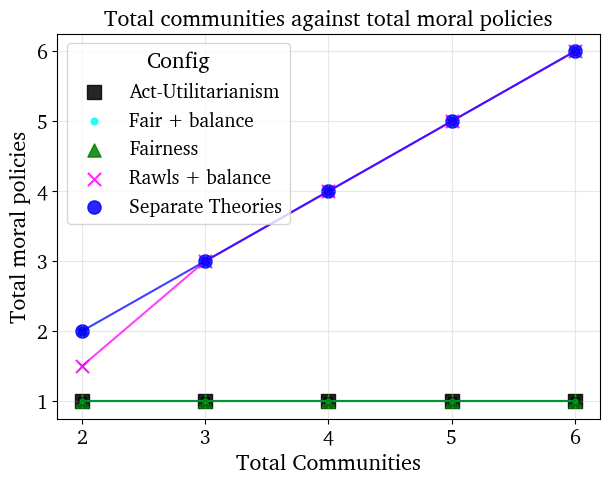

In [32]:
plot_df = df.reset_index().copy()
configs = ["Fair + balance", "Rawls + balance", "Act-Utilitarianism", "Separate Theories", "Fairness"]
plot_df = plot_df[plot_df["Config_name"].isin(configs)]

# Make sure communities is numeric
plot_df["communities"] = pd.to_numeric(plot_df["communities"], errors="coerce")
plot_df["Num_of_min_non_accept"] = pd.to_numeric(
    plot_df["Num_of_min_non_accept"],
    errors="coerce"
)

# Drop rows where conversion failed
plot_df = plot_df.dropna(subset=["communities", "Num_of_min_non_accept"])

avg_df = (
    plot_df
    .groupby(["Config_name", "communities"], as_index=False)["Num_of_min_non_accept"]
    .mean()
    .sort_values(["Config_name", "communities"])
)

fig, ax = plt.subplots(figsize=(7, 5))



for config, group in avg_df.groupby("Config_name", sort=False):
    x = group["communities"].astype(float)

    ax.scatter(
        x=x,
        y=group["Num_of_min_non_accept"],
        s=90,
        alpha=0.85,
        marker=markers.get(config, "o"),
        label=config,
        c=colours.get(config, "black")
    )

    ax.plot(
        x,
        group["Num_of_min_non_accept"],
        alpha=0.75,
        marker=markers.get(config, "o"),
        c=colours.get(config, "black")

    )

ax.set_xlabel("Total Communities")
ax.set_ylabel("Total moral policies")
ax.set_title("Total communities against total moral policies")

ax.set_xticks(sorted(avg_df["communities"].unique()))

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.show()

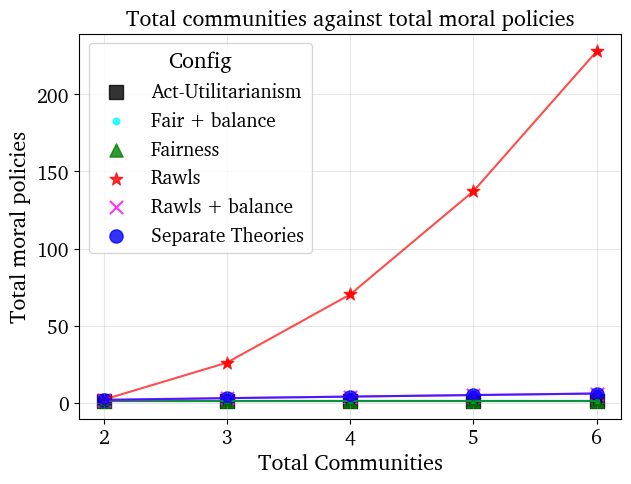

In [34]:
plot_df = df.reset_index().copy()

# Keep both configurations
plot_df = plot_df[plot_df["Config_name"].isin(["Rawls", "Fair + balance", "Rawls + balance", "Act-Utilitarianism", "Separate Theories", "Fairness"])]

# Average Num_of_min_non_accept for each Config_name and number of communities
avg_df = (
    plot_df
    .groupby(["Config_name", "communities"], as_index=False)["Num_of_min_non_accept"]
    .mean()
    .sort_values(["Config_name", "communities"])
)

fig, ax = plt.subplots(figsize=(7, 5))

for config, group in avg_df.groupby("Config_name"):
    ax.scatter(
        x=group["communities"],
        y=group["Num_of_min_non_accept"],
        s=90,
        alpha=0.8,
        label=config,
        marker=markers.get(config, "o"),
        c=colours[config]
    )

    ax.plot(
        group["communities"],
        group["Num_of_min_non_accept"],
        alpha=0.7,
        marker=markers.get(config, "o"),
        c=colours[config]

    )

ax.set_xlabel("Total Communities")
ax.set_ylabel("Total moral policies")
ax.set_title("Total communities against total moral policies")

ax.grid(True, alpha=0.3)
ax.legend(title="Config")

plt.show()

In [35]:
cols = [f"{t}:wellbeing" for t in teams]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=[f"{t}:wellbeing" for t in teams], envRepetitions=env_reps))
for t in cols:
    worth_df[t] = pd.to_numeric(worth_df[t])
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df['communities'] = worth_df['Config_name'].str[:1]
worth_df["Config_name"] = np.select(
    [
        worth_df["Config_name"].str.contains("fair_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("rawls_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("add", case=False, na=False),
        worth_df["Config_name"].str.contains("bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Rawls + Separate",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=worth_df["Config_name"]
)
worth_df.groupby(['Config_name', 'Env_rep', 'communities', 'Horizon'], sort=False, as_index=False).head()

,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,4,0,0.0,0.0000,1.3333,NaN,NaN,NaN,NaN,2
1,Separate Theories,0,4,0,1.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2
2,Separate Theories,0,4,1,1.0,0.0000,1.3333,NaN,NaN,NaN,NaN,2
3,Fairness,0,4,0,0.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2
4,Fair + Separate,0,4,0,1.0,0.6667,0.0000,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1265,Rawls,0,7,0,0.0,0.0139,0.0000,0.1343,0.0161,0.0000,0.0000,6
1266,Rawls,0,7,1,0.0,0.0161,0.0000,0.0000,0.2801,0.0000,0.0000,6
1267,Rawls,0,7,2,0.0,0.0201,0.0000,0.0000,0.0000,0.0000,1.1268,6
1268,Rawls,0,7,3,0.0,0.0000,0.0000,0.0683,0.0076,0.4757,0.0000,6


In [36]:

# ------------------------------------------------------------
# Reshape community wellbeing columns into long format
# ------------------------------------------------------------

wellbeing_long = worth_df.melt(
    id_vars=[
        "Config_name",
        "Env_rep",
        "Horizon",
        "Moral_policy_idx",
        "Non-acceptability",
        "communities",
    ],
    value_vars=cols,
    var_name="Community",
    value_name="Wellbeing"
)

# Remove wellbeing columns for communities that do not exist
wellbeing_long = wellbeing_long.dropna(subset=["Wellbeing"])

# ------------------------------------------------------------
# First calculate each statistic separately for every horizon
# ------------------------------------------------------------

horizon_stats = (
    wellbeing_long
    .groupby(["Config_name", "Horizon"])["Wellbeing"]
    .agg(
        Minimum="min",
        Maximum="max",
        Average="mean",
        Std_deviation=lambda x: x.std(ddof=0)
    )
    .reset_index()
)

# Convert the statistic columns into long format:
#
# Config_name | Horizon | Statistic | Value
#
horizon_stats_long = horizon_stats.melt(
    id_vars=["Config_name", "Horizon"],
    value_vars=[
        "Minimum",
        "Maximum",
        "Average",
        "Std_deviation"
    ],
    var_name="Statistic",
    value_name="Value"
)

# ------------------------------------------------------------
# Summarise each statistic across horizons
# ------------------------------------------------------------

plot_stats = (
    horizon_stats_long
    .groupby(["Config_name", "Statistic"])["Value"]
    .agg(
        Bar_height="mean",
        Horizon_min="min",
        Horizon_max="max"
    )
    .reset_index()
)

# Distances from the bar height to the lower and upper limits
plot_stats["Lower_error"] = (
    plot_stats["Bar_height"] - plot_stats["Horizon_min"]
)

plot_stats["Upper_error"] = (
    plot_stats["Horizon_max"] - plot_stats["Bar_height"]
)
plot_stats


,Config_name,Statistic,Bar_height,Horizon_min,Horizon_max,Lower_error,Upper_error
0,Act-Utilitarianism,Average,0.489211,0.279555,0.698870,0.209656,0.209659
1,Act-Utilitarianism,Maximum,2.333325,1.333300,3.333300,1.000025,0.999975
2,Act-Utilitarianism,Minimum,0.000000,0.000000,0.000000,0.000000,0.000000
3,Act-Utilitarianism,Std_deviation,0.853407,0.487670,1.219147,0.365737,0.365740
4,Fair + Separate,Average,0.103423,0.059095,0.147750,0.044328,0.044327
5,Fair + Separate,Maximum,1.166675,0.666700,1.666700,0.499975,0.500025
6,Fair + Separate,Minimum,0.000000,0.000000,0.000000,0.000000,0.000000
7,Fair + Separate,Std_deviation,0.270876,0.154791,0.386970,0.116086,0.116094
8,Fairness,Average,0.097095,0.059095,0.145140,0.038000,0.048045
9,Fairness,Maximum,0.805575,0.666700,1.000000,0.138875,0.194425


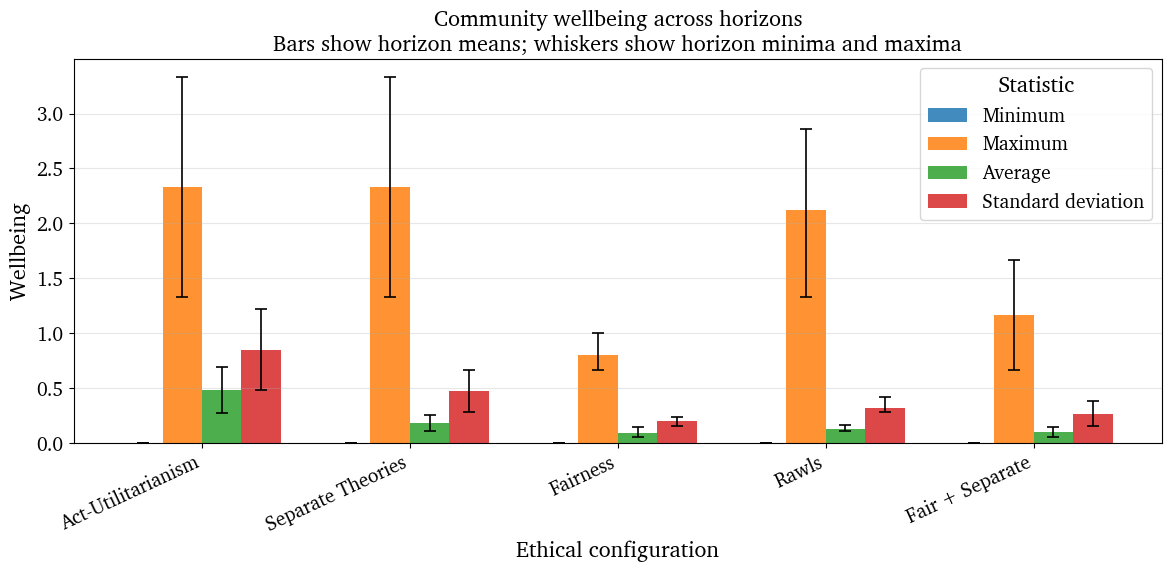

In [37]:
config_order = [
    "Act-Utilitarianism",
    "Separate Theories",
    "Fairness",
    "Rawls",
    "Fair + Separate",
    "Rawls + Separate",
]

statistic_order = [
    "Minimum",
    "Maximum",
    "Average",
    "Std_deviation",
]

statistic_labels = {
    "Minimum": "Minimum",
    "Maximum": "Maximum",
    "Average": "Average",
    "Std_deviation": "Standard deviation",
}

# Keep only configurations that actually occur
config_order = [
    config
    for config in config_order
    if config in plot_stats["Config_name"].unique()
]

x = np.arange(len(config_order))
bar_width = 0.19

fig, ax = plt.subplots(figsize=(12, 6))

for i, statistic in enumerate(statistic_order):

    stat_df = (
        plot_stats[plot_stats["Statistic"] == statistic]
        .set_index("Config_name")
        .reindex(config_order)
    )

    offset = (
        i - (len(statistic_order) - 1) / 2
    ) * bar_width

    # Asymmetric error bars:
    # first row = distance to minimum horizon value
    # second row = distance to maximum horizon value
    yerr = np.vstack([
        stat_df["Lower_error"].to_numpy(),
        stat_df["Upper_error"].to_numpy(),
    ])

    ax.bar(
        x + offset,
        stat_df["Bar_height"],
        width=bar_width,
        yerr=yerr,
        capsize=4,
        label=statistic_labels[statistic],
        alpha=0.85,
        error_kw={
            "elinewidth": 1.2,
            "capthick": 1.2,
        }
    )

ax.set_xticks(x)
ax.set_xticklabels(
    config_order,
    rotation=25,
    ha="right"
)

ax.set_xlabel("Ethical configuration")
ax.set_ylabel("Wellbeing")
ax.set_title(
    "Community wellbeing across horizons\n"
    "Bars show horizon means; whiskers show horizon minima and maxima"
)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Statistic")

plt.tight_layout()
plt.show()

In [38]:
cols = [f"{t}:wellbeing" for t in teams]

# ------------------------------------------------------------
# 1. Calculate community statistics within each individual policy
# ------------------------------------------------------------

# The wellbeing columns form the observations for each policy.
# NaN values correspond to communities that do not exist.
policy_wellbeing = worth_df[cols]

policy_stats = worth_df[
    [
        "Config_name",
        "Env_rep",
        "Horizon",
        "Moral_policy_idx",
        "communities",
    ]
].copy()

policy_stats["Minimum"] = policy_wellbeing.min(axis=1, skipna=True)
policy_stats["Maximum"] = policy_wellbeing.max(axis=1, skipna=True)
policy_stats["Average"] = policy_wellbeing.mean(axis=1, skipna=True)

# ddof=0 gives the population standard deviation across the communities
# within each policy.
policy_stats["Std_deviation"] = policy_wellbeing.std(
    axis=1,
    skipna=True,
    ddof=0
)

print("Statistics for each policy:")
display(policy_stats.head())

Statistics for each policy:


,Config_name,Env_rep,Horizon,Moral_policy_idx,communities,Minimum,Maximum,Average,Std_deviation
0,Act-Utilitarianism,0,4,0,2,0.0,1.3333,0.66665,0.66665
1,Separate Theories,0,4,0,2,0.0,0.6667,0.33335,0.33335
2,Separate Theories,0,4,1,2,0.0,1.3333,0.66665,0.66665
3,Fairness,0,4,0,2,0.0,0.6667,0.33335,0.33335
4,Fair + Separate,0,4,0,2,0.0,0.6667,0.33335,0.33335


In [39]:
stat_columns = [
    "Minimum",
    "Maximum",
    "Average",
    "Std_deviation",
]

config_horizon_stats = (
    policy_stats
    .groupby(
        ["Config_name", "Horizon"],
        as_index=False
    )[stat_columns]
    .mean()
)

print("Average policy statistics for each configuration–horizon pair:")
display(config_horizon_stats)

Average policy statistics for each configuration–horizon pair:


,Config_name,Horizon,Minimum,Maximum,Average,Std_deviation
0,Act-Utilitarianism,4,0.000000,1.118220,0.338014,0.491767
1,Act-Utilitarianism,5,0.000000,1.677300,0.507016,0.737639
2,Act-Utilitarianism,6,0.000000,2.236380,0.676018,0.983511
3,Act-Utilitarianism,7,0.000000,2.795480,0.845019,1.229389
4,Fair + Separate,4,0.000000,0.236380,0.096018,0.112673
5,Fair + Separate,5,0.000000,0.354600,0.144032,0.169021
6,Fair + Separate,6,0.000000,0.472780,0.192035,0.225352
7,Fair + Separate,7,0.000000,0.591000,0.240054,0.281702
8,Fairness,4,0.000000,0.236380,0.096018,0.112673
9,Fairness,5,0.000000,0.354600,0.144032,0.169021


In [40]:
config_horizon_long = config_horizon_stats.melt(
    id_vars=["Config_name", "Horizon"],
    value_vars=stat_columns,
    var_name="Statistic",
    value_name="Value"
)

plot_stats = (
    config_horizon_long
    .groupby(
        ["Config_name", "Statistic"],
        as_index=False
    )["Value"]
    .agg(
        Bar_height="mean",
        Horizon_min="min",
        Horizon_max="max",
    )
)

# Asymmetric distances from the bar height to the horizon limits
plot_stats["Lower_error"] = (
    plot_stats["Bar_height"] - plot_stats["Horizon_min"]
)

plot_stats["Upper_error"] = (
    plot_stats["Horizon_max"] - plot_stats["Bar_height"]
)

print("Values used for plotting:")
display(plot_stats)

Values used for plotting:


,Config_name,Statistic,Bar_height,Horizon_min,Horizon_max,Lower_error,Upper_error
0,Act-Utilitarianism,Average,0.591517,0.338014,0.845019,0.253503,0.253502
1,Act-Utilitarianism,Maximum,1.956845,1.118220,2.795480,0.838625,0.838635
2,Act-Utilitarianism,Minimum,0.000000,0.000000,0.000000,0.000000,0.000000
3,Act-Utilitarianism,Std_deviation,0.860577,0.491767,1.229389,0.368809,0.368812
4,Fair + Separate,Average,0.168035,0.096018,0.240054,0.072016,0.072019
5,Fair + Separate,Maximum,0.413690,0.236380,0.591000,0.177310,0.177310
6,Fair + Separate,Minimum,0.000000,0.000000,0.000000,0.000000,0.000000
7,Fair + Separate,Std_deviation,0.197187,0.112673,0.281702,0.084514,0.084515
8,Fairness,Average,0.158401,0.096018,0.236791,0.062383,0.078390
9,Fairness,Maximum,0.273190,0.226020,0.354600,0.047170,0.081410


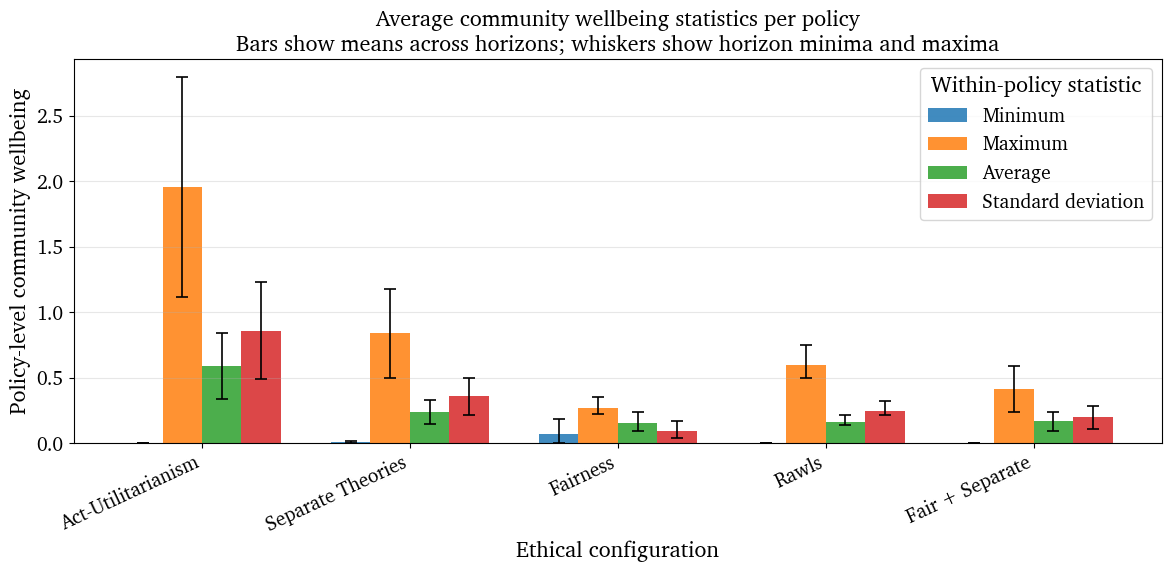

In [41]:
config_order = [
    "Act-Utilitarianism",
    "Separate Theories",
    "Fairness",
    "Rawls",
    "Fair + Separate",
    "Rawls + Separate",
]

statistic_order = [
    "Minimum",
    "Maximum",
    "Average",
    "Std_deviation",
]

statistic_labels = {
    "Minimum": "Minimum",
    "Maximum": "Maximum",
    "Average": "Average",
    "Std_deviation": "Standard deviation",
}

# Keep only configurations present in the data
available_configs = set(plot_stats["Config_name"])

config_order = [
    config
    for config in config_order
    if config in available_configs
]

# Append any unexpected configurations not listed above
config_order += [
    config
    for config in plot_stats["Config_name"].unique()
    if config not in config_order
]

x = np.arange(len(config_order))
bar_width = 0.19

fig, ax = plt.subplots(figsize=(12, 6))

for i, statistic in enumerate(statistic_order):
    stat_df = (
        plot_stats[plot_stats["Statistic"] == statistic]
        .set_index("Config_name")
        .reindex(config_order)
    )

    offset = (
        i - (len(statistic_order) - 1) / 2
    ) * bar_width

    values = stat_df["Bar_height"].to_numpy()

    yerr = np.vstack([
        stat_df["Lower_error"].to_numpy(),
        stat_df["Upper_error"].to_numpy(),
    ])

    ax.bar(
        x + offset,
        values,
        width=bar_width,
        yerr=yerr,
        capsize=4,
        label=statistic_labels[statistic],
        alpha=0.85,
        error_kw={
            "elinewidth": 1.2,
            "capthick": 1.2,
        },
    )

ax.set_xticks(x)
ax.set_xticklabels(
    config_order,
    rotation=25,
    ha="right",
)

ax.set_xlabel("Ethical configuration")
ax.set_ylabel("Policy-level community wellbeing")
ax.set_title(
    "Average community wellbeing statistics per policy\n"
    "Bars show means across horizons; whiskers show horizon minima and maxima"
)

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Within-policy statistic")

plt.tight_layout()
plt.show()